# Notebook 1: Intuizione e Previsione della Domanda


**Argomenti:** Demand Prediction + Riconoscimento Immagini come motivazione per reti profonde

---


### Cosa imparerai in QUESTO notebook:

1. **Lo scenario di business "Demand Prediction"** — l'approccio unico per introdurre le reti neurali attraverso un problema di previsione della domanda
2. **Feature engineering automatico vs manuale** — il vero potere delle reti neurali
5. **AGI vs ANI** — la distinzione tra intelligenza artificiale ristretta e generale

In [1]:
# Importazioni necessarie
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configurazione grafici
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Funzione sigmoide 
def sigmoide(z):
    """Funzione sigmoide: σ(z) = 1 / (1 + e^(-z))"""
    return 1 / (1 + np.exp(-z))

---
## Parte 1: Lo Scenario "Demand Prediction"

### Il Contesto di Business

Andrew Ng introduce le reti neurali con un esempio concreto e pratico:

> **Sei un rivenditore online di t-shirt.** Vuoi prevedere in anticipo se un nuovo design diventerà un **best-seller**. Questa informazione è estremamente preziosa perché ti permette di:
> - Ordinare più scorte in anticipo
> - Pianificare campagne di marketing mirate
> - Ottimizzare le strategie di prezzo

Questo è un problema di **classificazione binaria**: per ogni t-shirt, vogliamo prevedere **y = 1** (best-seller) o **y = 0** (non best-seller).

### L'Intuizione Chiave: Feature Intermedie

Ng argomenta che il successo di una t-shirt dipende da **tre concetti astratti di alto livello**:

| Concetto Intermedio | Feature di Input Rilevanti | Interpretazione |
|:---|:---|:---|
| **Accessibilità** (Affordability) | Prezzo, Costo di spedizione | Quanto è economica per l'acquirente? |
| **Consapevolezza** (Awareness) | Budget marketing | Quanto è conosciuta dal pubblico? |
| **Qualità Percepita** (Perceived Quality) | Prezzo, Qualità materiale | Il cliente la percepisce come di qualità? |

**Nota importante:** Il prezzo influenza sia l'accessibilità (negativamente) sia la qualità percepita (positivamente) — un prezzo più alto può far percepire il prodotto come più pregiato. Questo è un effetto psicologico ben noto nel marketing.

---
## Esercizio 1: Simulare il Ragionamento di Business (Livello: Base)

Prima di usare una rete neurale, simuliamo il ragionamento di business di Ng **manualmente**.

Abbiamo un catalogo di t-shirt con 4 feature. Il tuo compito è:
1. Calcolare manualmente i "punteggi" di accessibilità, consapevolezza e qualità percepita
2. Combinare questi punteggi per prevedere se la t-shirt sarà un best-seller
3. Confrontare il tuo ragionamento con quello di un neurone

### Dataset di esempio:

In [2]:
# Dataset: catalogo t-shirt
# Colonne: [prezzo (€), costo_spedizione (€), budget_marketing (€), qualità_materiale (1-10)]
catalogo = np.array([
    [15.0,  3.0,  2000.0, 6.0],   # T-shirt A: economica, buon marketing
    [45.0,  8.0,   500.0, 9.0],   # T-shirt B: costosa, alta qualità
    [25.0,  5.0,  3000.0, 7.0],   # T-shirt C: prezzo medio, ottimo marketing
    [10.0,  2.0,   100.0, 3.0],   # T-shirt D: economica, bassa qualità, poco marketing
    [30.0,  4.0,  1500.0, 8.0],   # T-shirt E: prezzo medio-alto, buona qualità
])

nomi_tshirt = ['A', 'B', 'C', 'D', 'E']
nomi_feature = ['Prezzo (€)', 'Spedizione (€)', 'Marketing (€)', 'Qualità (1-10)']

# Stampa il catalogo in modo leggibile
print("CATALOGO T-SHIRT")
print("=" * 70)
print(f"{'T-shirt':<10} {'Prezzo':>8} {'Spediz.':>8} {'Marketing':>10} {'Qualità':>8}")
print("-" * 70)
for i, nome in enumerate(nomi_tshirt):
    print(f"  {nome:<8} {catalogo[i,0]:>7.0f}€ {catalogo[i,1]:>7.0f}€ {catalogo[i,2]:>9.0f}€ {catalogo[i,3]:>7.0f}")

CATALOGO T-SHIRT
T-shirt      Prezzo  Spediz.  Marketing  Qualità
----------------------------------------------------------------------
  A             15€       3€      2000€       6
  B             45€       8€       500€       9
  C             25€       5€      3000€       7
  D             10€       2€       100€       3
  E             30€       4€      1500€       8


In [3]:
# COMPITO 1: Ragionamento manuale
# Per ogni t-shirt, assegna un punteggio da 0 (basso) a 1 (alto) per:
# - Accessibilità: quanto è economica? (prezzo + spedizione bassi → alta accessibilità)
# - Consapevolezza: quanto è conosciuta? (marketing alto → alta consapevolezza)
# - Qualità percepita: sembra di qualità? (prezzo alto + qualità materiale alta → alta qualità percepita)

# --- COMPLETA QUI ---
# Suggerimento: ragiona in modo intuitivo. Non serve una formula precisa.
# Esempio per T-shirt A: prezzo basso + spedizione bassa → accessibilità ALTA (~0.9)

ragionamento = {
    'A': {'accessibilita': 0.9, 'consapevolezza': 0.7, 'qualita_percepita': 0.4},
    'B': {'accessibilita': 0.2, 'consapevolezza': 0.2, 'qualita_percepita': 0.9},
    'C': {'accessibilita': 0.6, 'consapevolezza': 0.9, 'qualita_percepita': 0.6},
    'D': {'accessibilita': 0.95, 'consapevolezza': 0.05, 'qualita_percepita': 0.1},
    'E': {'accessibilita': 0.5, 'consapevolezza': 0.5, 'qualita_percepita': 0.7},
}

# Stampa il tuo ragionamento
print("IL TUO RAGIONAMENTO DI BUSINESS")
print("=" * 60)
for nome, punteggi in ragionamento.items():
    print(f"T-shirt {nome}: Accessibilità={punteggi['accessibilita']}, "
          f"Consapevolezza={punteggi['consapevolezza']}, "
          f"Qualità Percepita={punteggi['qualita_percepita']}")

IL TUO RAGIONAMENTO DI BUSINESS
T-shirt A: Accessibilità=0.9, Consapevolezza=0.7, Qualità Percepita=0.4
T-shirt B: Accessibilità=0.2, Consapevolezza=0.2, Qualità Percepita=0.9
T-shirt C: Accessibilità=0.6, Consapevolezza=0.9, Qualità Percepita=0.6
T-shirt D: Accessibilità=0.95, Consapevolezza=0.05, Qualità Percepita=0.1
T-shirt E: Accessibilità=0.5, Consapevolezza=0.5, Qualità Percepita=0.7


In [4]:
# COMPITO 2: Ora simuliamo lo stesso ragionamento con NEURONI
# Ogni concetto intermedio è calcolato da un neurone con pesi specifici.

# Neurone "Accessibilità": pesi negativi per prezzo e spedizione
# (costo più alto → meno accessibile)
w_access = np.array([-0.08, -0.12, 0.0, 0.0])  # solo prezzo e spedizione contano
b_access = 3.0

# Neurone "Consapevolezza": peso positivo per marketing
w_consap = np.array([0.0, 0.0, 0.001, 0.0])  # solo marketing conta
b_consap = -1.0

# Neurone "Qualità Percepita": pesi positivi per prezzo e qualità materiale
w_qualita = np.array([0.04, 0.0, 0.0, 0.15])  # prezzo e qualità contano
b_qualita = -2.5

# --- COMPLETA QUI ---
# Per ogni t-shirt nel catalogo, calcola le 3 attivazioni intermedie
# usando la formula: a = sigmoide(w · x + b)
# Suggerimento: usa np.dot(w, x) per il prodotto scalare

print("CALCOLO DEI NEURONI")
print("=" * 70)
print(f"{'T-shirt':<10} {'Accessibilità':>14} {'Consapevolezza':>16} {'Qualità Perc.':>14}")
print("-" * 70)

for i, nome in enumerate(nomi_tshirt):
    x = catalogo[i]
    # --- COMPLETA QUI ---
    a_access = sigmoide(np.dot(w_access, x) + b_access)    # DA COMPLETARE: sigmoide(np.dot(w_access, x) + b_access)
    a_consap = sigmoide(np.dot(w_consap, x) + b_consap)    # DA COMPLETARE
    a_qualita = sigmoide(np.dot(w_qualita, x) + b_qualita)   # DA COMPLETARE
    print(f"  {nome:<8} {a_access:>13.4f} {a_consap:>15.4f} {a_qualita:>13.4f}")

CALCOLO DEI NEURONI
T-shirt     Accessibilità   Consapevolezza  Qualità Perc.
----------------------------------------------------------------------
  A               0.8085          0.7311        0.2689
  B               0.1736          0.3775        0.6570
  C               0.5987          0.8808        0.3894
  D               0.8765          0.2891        0.1611
  E               0.5300          0.6225        0.4750


In [5]:
# COMPITO 3: Combina le feature intermedie con un neurone di output
# Il neurone di output prende le 3 attivazioni intermedie e produce
# la probabilità finale di essere un best-seller

w_output = np.array([0.6, 0.5, 0.4])  # pesi per accessibilità, consapevolezza, qualità
b_output = -0.8

print("PREDIZIONE FINALE")
print("=" * 50)
for i, nome in enumerate(nomi_tshirt):
    x = catalogo[i]
    
    # Layer nascosto: calcola le 3 feature intermedie
    # --- COMPLETA QUI ---
    a_hidden = np.array([
        sigmoide(np.dot(w_access, x) + b_access),  # DA COMPLETARE: accessibilità
        sigmoide(np.dot(w_consap, x) + b_consap),  # DA COMPLETARE: consapevolezza
        sigmoide(np.dot(w_qualita, x) + b_qualita)  # DA COMPLETARE: qualità percepita
    ])
    
    # Layer di output: combina le feature intermedie
    # --- COMPLETA QUI ---
    prob_bestseller = sigmoide(np.dot(w_output, a_hidden) + b_output)  # DA COMPLETARE: sigmoide(np.dot(w_output, a_hidden) + b_output)
    
    decisione = "✓ BEST-SELLER" if prob_bestseller >= 0.5 else "✗ Non best-seller"
    print(f"  T-shirt {nome}: P(best-seller) = {prob_bestseller:.1%} → {decisione}")

PREDIZIONE FINALE
  T-shirt A: P(best-seller) = 53.9% → ✓ BEST-SELLER
  T-shirt B: P(best-seller) = 43.9% → ✗ Non best-seller
  T-shirt C: P(best-seller) = 53.9% → ✓ BEST-SELLER
  T-shirt D: P(best-seller) = 48.4% → ✗ Non best-seller
  T-shirt E: P(best-seller) = 50.5% → ✓ BEST-SELLER


---
## Esercizio 2: Demand Prediction con Dataset Realistico (Livello: Avanzato)

Ora mettiamo tutto insieme: creiamo un dataset realistico di prodotti e costruiamo una rete neurale a 2 layer **da zero** (senza TensorFlow) per prevedere i best-seller.

### Compito:
1. Genera un dataset sintetico di 200 prodotti con 4 feature
2. Crea le etichette basandoti su una combinazione realistica delle feature
3. Implementa la forward propagation completa (2 layer)
4. Visualizza come i neuroni nascosti "vedono" i dati

In [6]:
np.random.seed(2024)

# 1. Genera il dataset
n_prodotti = 200
prezzo = np.random.uniform(8, 60, n_prodotti)
spedizione = np.random.uniform(1, 10, n_prodotti)
marketing = np.random.uniform(50, 5000, n_prodotti)
qualita = np.random.uniform(1, 10, n_prodotti)

# Combina in una matrice (200, 4)
X = np.column_stack([prezzo, spedizione, marketing, qualita])

# 2. Crea etichette realistiche
# Un prodotto è best-seller se ha buona accessibilità + consapevolezza + qualità percepita
# Calcola un "punteggio" per ogni prodotto basandoti sulle 3 dimensioni:
# - accessibilità: inversamente proporzionale a (prezzo + spedizione)
# - consapevolezza: proporzionale al marketing
# - qualità percepita: proporzionale a (prezzo * 0.3 + qualità * 0.7)
costo_totale = prezzo + spedizione
accessibilita_score = 1 - (costo_totale / costo_totale.max())
consapevolezza_score = marketing / marketing.max()
qualita_score = (prezzo * 0.3 + qualita * 0.7) / (60 * 0.3 + 10 * 0.7)

punteggio = 0.35 * accessibilita_score + 0.35 * consapevolezza_score + 0.30 * qualita_score

soglia = np.percentile(punteggio, 60)
rumore = np.random.normal(0, 0.05, n_prodotti)
y = ((punteggio + rumore) > soglia).astype(int)

print(f"Dataset: {X.shape[0]} prodotti, {X.shape[1]} feature")
print(f"Best-seller: {y.sum()} ({y.mean():.1%})")
print(f"Non best-seller: {(1-y).sum()} ({(1-y).mean():.1%})")


Dataset: 200 prodotti, 4 feature
Best-seller: 80 (40.0%)
Non best-seller: 120 (60.0%)


In [7]:
# 3. Implementa la forward propagation completa
# Rete: 4 input → 3 neuroni nascosti → 1 neurone output

# Normalizza gli input (fondamentale per le reti neurali!)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# Pesi "addestrati" (simulati — in realtà sarebbero appresi con backpropagation)
# Layer nascosto: 3 neuroni, 4 input
W1 = np.array([
    [-1.2, -0.8,  0.1,  0.0],   # Neurone "accessibilità"
    [ 0.0,  0.0,  1.5,  0.1],   # Neurone "consapevolezza"
    [ 0.5,  0.0,  0.0,  1.0],   # Neurone "qualità percepita"
])
b1 = np.array([0.5, -0.5, -0.3])

# Layer output: 1 neurone, 3 input
W2 = np.array([[0.8, 0.7, 0.6]])
b2 = np.array([-1.0])

# --- COMPLETA QUI ---
# Implementa la forward propagation per TUTTI i prodotti contemporaneamente
# Suggerimento: usa operazioni matriciali
# Z1 = X_norm @ W1.T + b1   (forma: 200 x 3)
# A1 = sigmoide(Z1)          (forma: 200 x 3)
# Z2 = A1 @ W2.T + b2        (forma: 200 x 1)
# A2 = sigmoide(Z2)          (forma: 200 x 1)

Z1 = X_norm @ W1.T + b1 # DA COMPLETARE
A1 = sigmoide(Z1)  # DA COMPLETARE
Z2 = A1 @ W2.T + b2 # DA COMPLETARE
A2 = sigmoide(Z2)  # DA COMPLETARE

predizioni = (A2.flatten() >= 0.5).astype(int)
accuratezza = (predizioni == y).mean()
print(f"Accuratezza della rete: {accuratezza:.1%}")

Accuratezza della rete: 77.0%


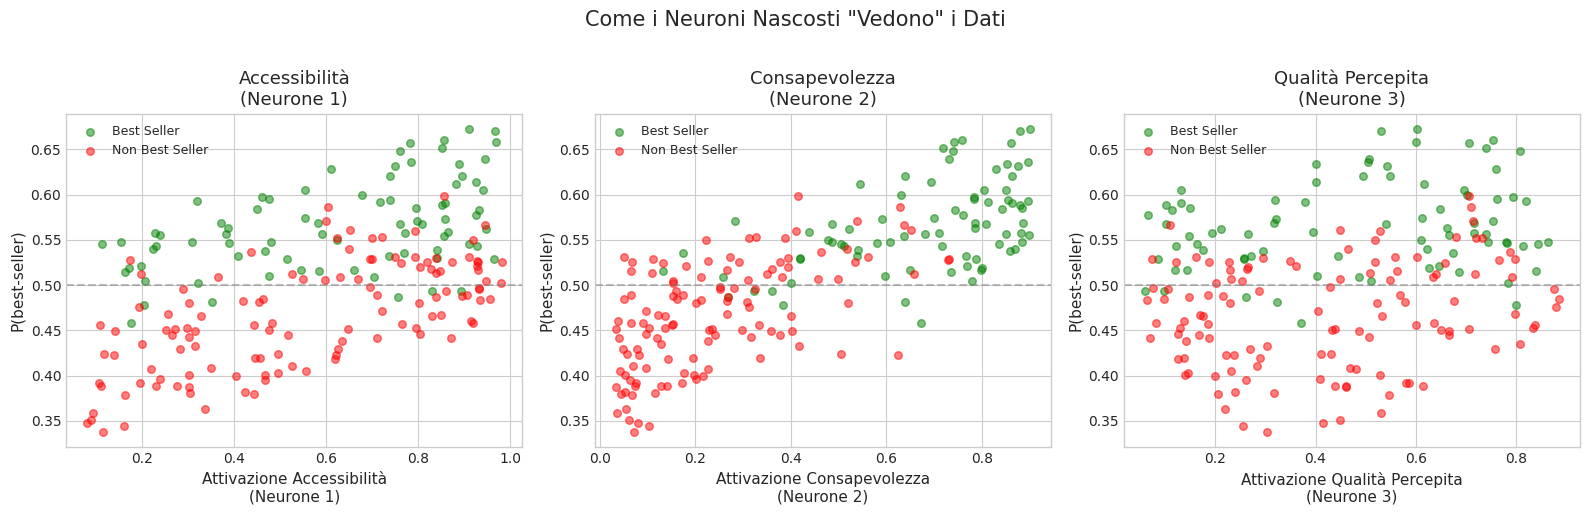

In [11]:
# 4. Visualizza come i neuroni nascosti "vedono" i dati
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

nomi_neuroni = ['Accessibilità\n(Neurone 1)', 'Consapevolezza\n(Neurone 2)', 'Qualità Percepita\n(Neurone 3)']
colori = ['#2196F3', '#4CAF50', '#FF9800']

for j in range(3):
                      
    # --- COMPLETA QUI ---
    # Per ogni neurone nascosto, crea uno scatter plot:
    # - Asse X: attivazione del neurone (A1[:, j])
    # - Asse Y: probabilità di best-seller (A2.flatten())
    # - Colore: verde per best-seller reali, rosso per non best-seller
    
    mask_bs = y == 1
    axes[j].scatter(A1[mask_bs, j], A2[mask_bs].flatten(), c='green', alpha=0.5, s=30, label='Best Seller')
    axes[j].scatter(A1[~mask_bs, j], A2[~mask_bs].flatten(), c='red', alpha=0.5, s=30, label='Non Best Seller')
    
    axes[j].set_xlabel(f'Attivazione {nomi_neuroni[j]}', fontsize=11)
    axes[j].set_ylabel('P(best-seller)', fontsize=11)
    axes[j].set_title(nomi_neuroni[j], fontsize=13)
    axes[j].legend(fontsize=9)
    axes[j].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Come i Neuroni Nascosti "Vedono" i Dati', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()